#  Sales Data Analysis Project 

This notebook includes:
- Data Cleaning (mean/median/mode)
- Advanced EDA
- Correlation Heatmap
- Business Insights
- Visualizations


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Salesorder.csv')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


##  Data Cleaning

In [2]:
# Convert numeric columns
numeric_columns = ['sales', 'quantity', 'discount', 'profit', 'shipping_cost']

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Missing values check
print(df.isnull().sum())

# Fill missing values
df['sales'] = df['sales'].fillna(df['sales'].mean())
df['profit'] = df['profit'].fillna(df['profit'].median())

# Categorical fill
if 'region' in df.columns:
    df['region'] = df['region'].fillna(df['region'].mode()[0])

# Drop duplicates
df = df.drop_duplicates()

# Date conversion
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')

df.isnull().sum()

order_id             0
order_date           0
ship_date            0
ship_mode            0
customer_name        0
segment              0
state                0
country              0
market               0
region               0
product_id           0
category             0
sub_category         0
product_name         0
sales             2630
quantity             0
discount             0
profit               0
shipping_cost        0
order_priority       0
year                 0
dtype: int64


order_id              0
order_date        31223
ship_date         31456
ship_mode             0
customer_name         0
segment               0
state                 0
country               0
market                0
region                0
product_id            0
category              0
sub_category          0
product_name          0
sales                 0
quantity              0
discount              0
profit                0
shipping_cost         0
order_priority        0
year                  0
dtype: int64

##  KPIs

In [3]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df.shape[0]

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 8258604.914097822
Total Profit: 1469034.82128
Total Orders: 51290


##  EDA & Visualizations

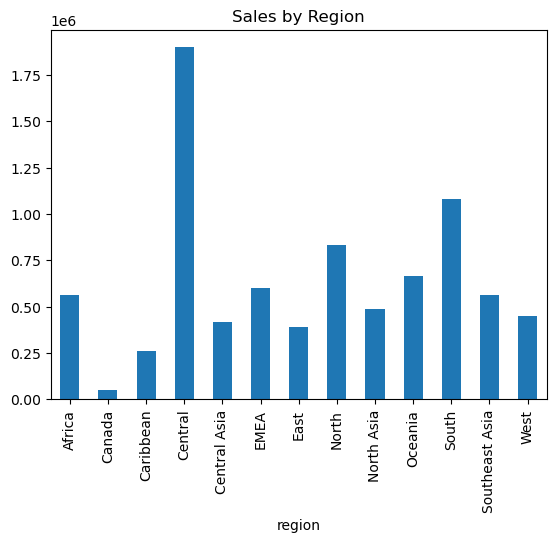

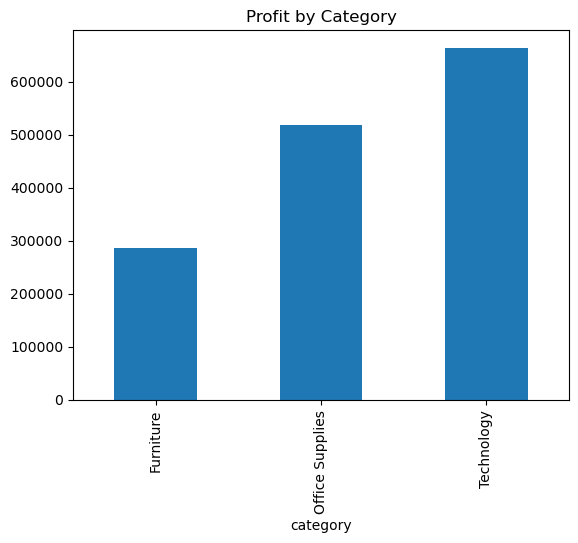

In [4]:
# Region-wise sales
region_sales = df.groupby('region')['sales'].sum()
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.show()

# Category profit
category_profit = df.groupby('category')['profit'].sum()
category_profit.plot(kind='bar')
plt.title("Profit by Category")
plt.show()

##  Correlation Heatmap

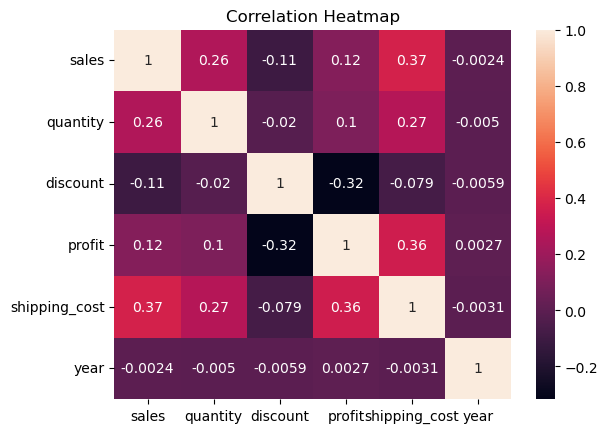

In [5]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

##  Time Analysis

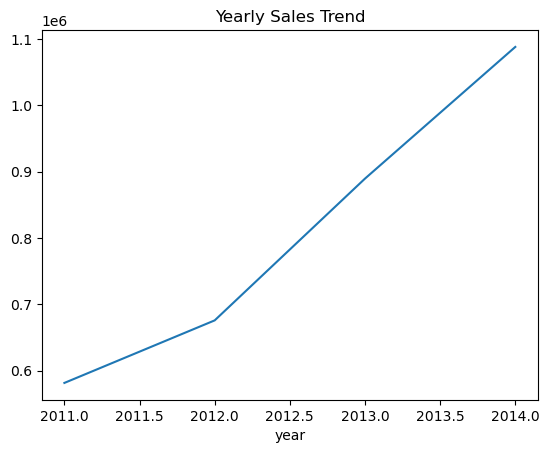

In [6]:
df['year'] = df['order_date'].dt.year

yearly_sales = df.groupby('year')['sales'].sum()
yearly_sales.plot(kind='line')
plt.title("Yearly Sales Trend")
plt.show()

## Business Insights

- Technology category shows highest profit  
- Furniture category has lower profitability  
- Sales trend is increasing over time  
- Certain regions perform better than others  
- Shipping cost impacts profit negatively  

  Recommendation:
- Focus on high-profit categories  
- Optimize cost in low-profit areas  
